# Práctica 2: Múltiples cúbits

## UNAM - Facultad de Ingeniería
## Temas selectos de Ingeniería en Computación III (Computación cuántica)
## Grupo: 1
## Semestre 2026-2

### Alumno: Gustavo Valenzuela Ascencio
### Profesora: Lic. Naomi Itzel Reyes Granados

# Ejercicio 1

1. Implementa el siguiente circuito cuántico con Qiskit y simúlalo. Recuerda que, por defecto, el estado inicial es $\ket{000}$, ¿cuál es el estado final? (mide los 3 qubits). El objetivo es averiguar qué hace el circuito cuántico.

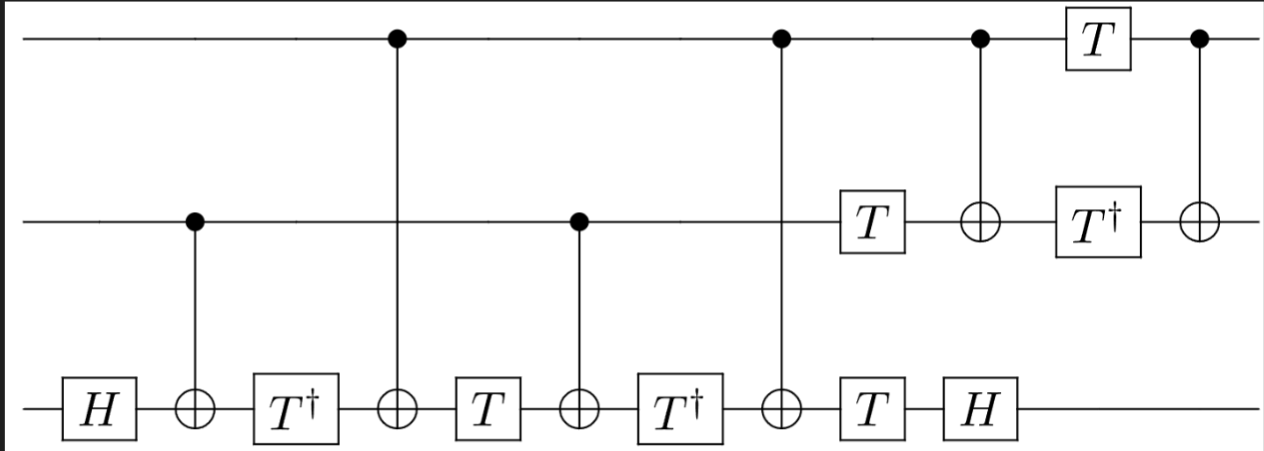

Para saber lo que hace el circuito es muy útil hacer una tabla de verdad:

|q2|q1|q0|$\rightarrow$|q2|q1|q0|
|:----:|:----:|:----:|:----:|:----:|:----:|:----:|
|0|0|0|$\rightarrow$|0|0|0|
|0|0|1|$\rightarrow$|0|0|1|
|0|1|0|$\rightarrow$|0|1|0|
|0|1|1|$\rightarrow$|0|1|1|
|1|0|0|$\rightarrow$|1|0|0|
|1|0|1|$\rightarrow$|1|0|1|
|1|1|0|$\rightarrow$|1|1|1|
|1|1|1|$\rightarrow$|1|1|0|

Donde $q2,q1,q0$ de la **izquierda** son los estados iniciales (antes de las compuertas) y los $q2,q1,q0$ de la **derecha** son los estados finales (después de las compuertas).

<br>

- Cumple con los siguientes puntos:
    - Cambia el estado inicial (aplicando compuertas $X$ en cada qubit, y la combinación de estas) para cubrir todas las posibilidades del lado izquierdo de la tabla de verdad ($q2,q1,q0$), es decir, los $2^3=8$ posibles estados iniciales.
        - Recuerda que $q0$ es el qubit de hasta arriba en el circuito (orden de Qiskit).
    - Simulación del circuito usando la clase `BasicSimulator` o la clase `StatevectorSampler` (como en los ejemplos anteriores).
        - Mostrar los histogramas.
        - Está prohibido usar Qiskit Aer (`qiskit-aer`). Muchos ejemplos en internet usan Qiskit Aer, pero no se puede usar en las tareas, así que realiza la adecuación pertinente del código.
    - Rellena toda la tabla (en markdown) con los resultados que obtengas de la medición al iniciar el circuito con cada estado posible.
        - Puedes usar un método de Python para que no tengas que repetir el mismo código tantas veces.
    - ¿Qué crees que hace este circuito?
        - Escribe tus conclusiones en una celda de markdown.
    

<br/>

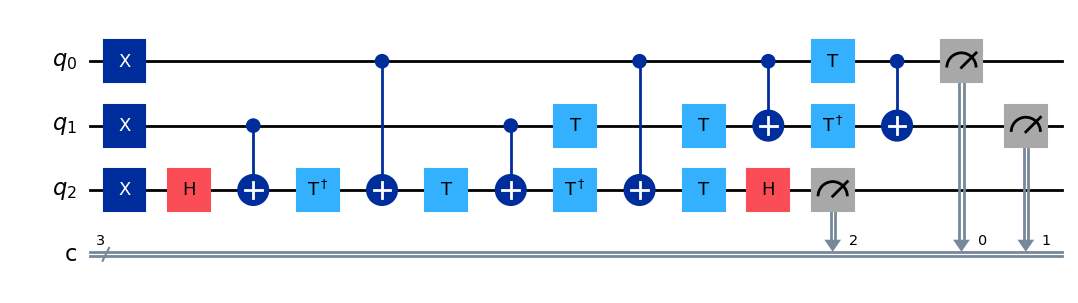

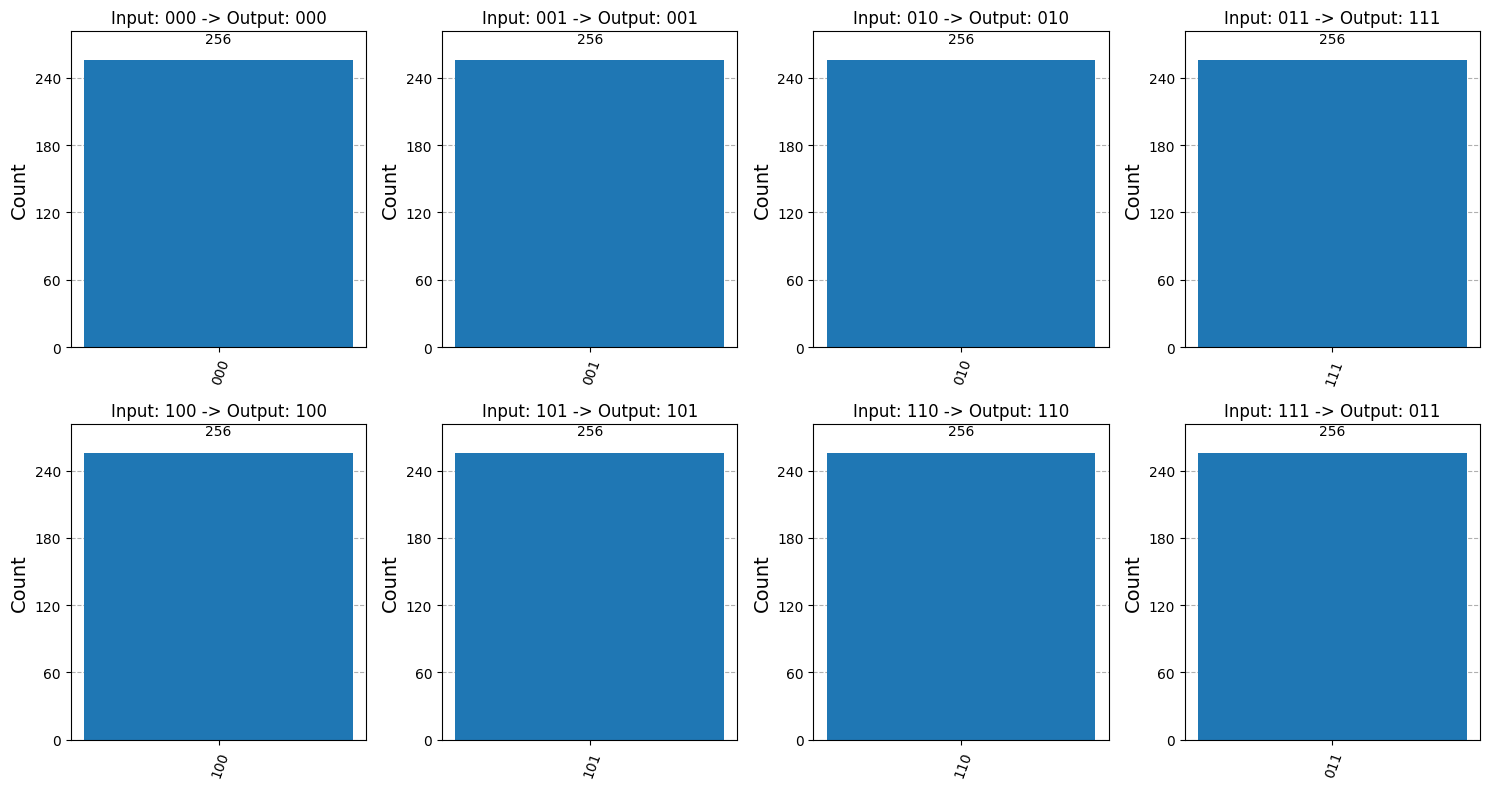

In [2]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
import matplotlib.pyplot as plt
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram


def run_circuit(q2: bool, q1: bool, q0: bool)-> QuantumCircuit:
    circuit = QuantumCircuit(3,3)
    
    if q2:
        circuit.x(2)
    if q1:
        circuit.x(1)
    if q0:
        circuit.x(0)

    circuit.h(2)
    circuit.cx(1,2)
    circuit.tdg(2)
    circuit.cx(0,2)
    circuit.t(2)
    circuit.cx(1,2)
    circuit.tdg(2)
    circuit.cx(0,2)
    circuit.t(1)
    circuit.t(2)
    circuit.h(2)
    circuit.t(1)
    circuit.cx(0,1)
    circuit.t(0)
    circuit.tdg(1)
    circuit.cx(0,1)
    #display(circuit.draw('mpl'))
    circuit.measure([0,1,2], [0,1,2])
    
    if(q0 == 1 and q1 == 1 and q2 == 1):
        display(circuit.draw('mpl'))
    return circuit

simulator = BasicSimulator()

fig,axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i in range(8):
    q2 = (i >> 2) & 1
    q1 = (i >> 1) & 1
    q0 = i & 1
    plt.sca(axes[i])
    circuit = run_circuit(q2, q1, q0)
    
    job = simulator.run(circuit, shots= 256)
    result = job.result()
    counts = result.get_counts(circuit)
    output = list(counts.keys())[0]
    plot_histogram(counts, ax=axes[i], title=f"Input: {q2}{q1}{q0} -> Output: {output}")

plt.tight_layout()
plt.show()

# Conclusión del ejercicio.

Este circuito implementa la compuerta de Toffoli, o $CCNOT$, que es una compuerta de control en la que un cúbit depende de dos cúbits de control. Si estos dos cúbits son 1 (es decir una compuerta AND), el cúbit dependiente se va a invertir.  

# Ejercicio 2

2. Implementa la compuerta $SWAP$ pero utilizando su equivalencia de tres compuertas de 2 qubits (tercer diagrama en [esta referencia](https://pennylane.ai/qml/glossary/what-is-a-swap-gate/)).
    1. Escribe el código.
    2. Realiza la silumación usando un estado en superposición equiprobable de todos los estados de dos qubits en tu computadora usando `BasicSimulator` (como en los ejemplos).
    3. Mostrar los histogramas.
        - Está prohibido usar Qiskit Aer (`qiskit-aer`). Muchos ejemplos en internet usan Qiskit Aer, pero no se puede usar en las tareas, así que realiza la adecuación pertinente del código.

<br/>

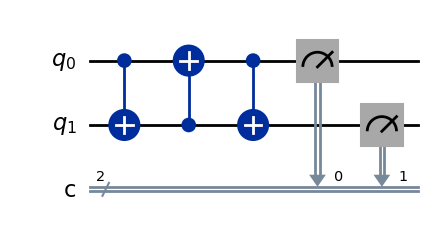

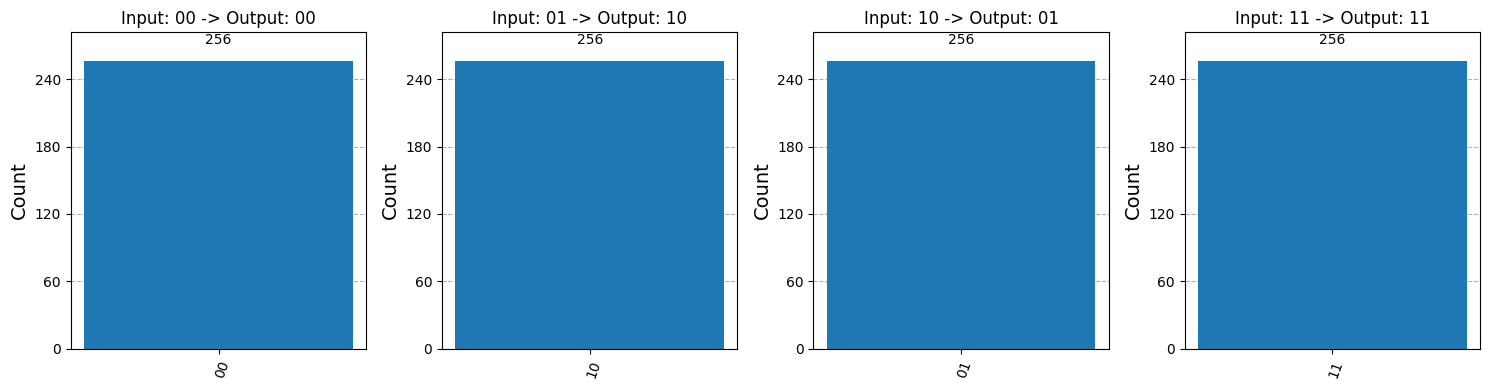

In [3]:
def swap_circuit(q1: bool, q0: bool) -> QuantumCircuit:
    swap_circuit = QuantumCircuit(2,2)

    if q1:
        swap_circuit.x(1)
    if q0:
        swap_circuit.x(0)

    swap_circuit.cx(0,1)
    swap_circuit.cx(1,0)
    swap_circuit.cx(0,1)
    swap_circuit.measure([0,1], [0,1])
    
    return swap_circuit

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()
for i in range(4):
    q1 = (i >> 1) & 1
    q0 = i & 1
    plt.sca(axes[i])
    circuit = swap_circuit(q1, q0)
    if i==0:
        display(circuit.draw('mpl'))
    job = simulator.run(circuit, shots= 256)
    result = job.result()
    counts = result.get_counts(circuit)
    output = list(counts.keys())[0] 
    plot_histogram(counts, ax=axes[i], title=f"Input: {q1}{q0} -> Output: {output}")
    
plt.tight_layout()
plt.show()

# Ejercicio 3

3. **[Opcional]** Implementa el siguiente circuito cuántico con Qiskit y simúlalo. ¿Qué crees que hace este circuito?

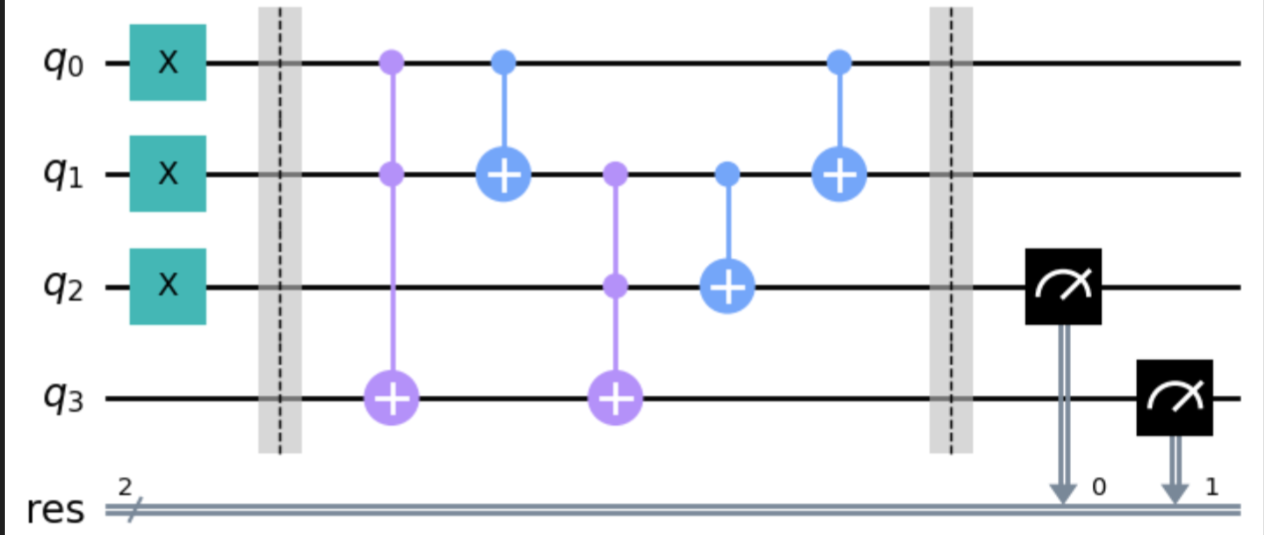

- Las barreras (líneas verticales grises) se agregan con `circuito.barrier()`.
- Implementa el circuito usando Qiskit.
- Las compuertas $X$ antes de la primer barrera son un ejemplo de inicialización del estado, en este caso se está iniciando en $\ket{0111}$ (recuerda el orden de Qiskit).
  - Cambia las compuertas $X$ para obtener todos los posibles estados de inicialización (son $2^4$ estados diferentes).
- Recuerda simular el circuito con los diferentes estados iniciales posibles, como en los ejemplos de este notebook (no uso de Qiskit Aer).
- En una celda de markdown describe lo que crees que hace este circuito cuántico.
    - Considera usar una tabla de verdad para averiguar lo que hace.

<br/>

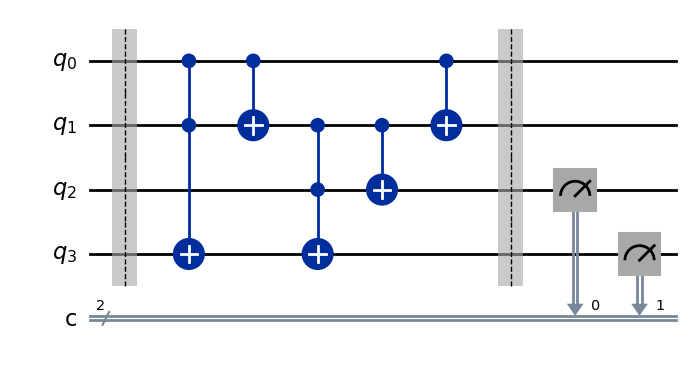

A, B, C_in: 000 -> Carry, Sum: 00
A, B, C_in: 100 -> Carry, Sum: 01
A, B, C_in: 010 -> Carry, Sum: 01
A, B, C_in: 110 -> Carry, Sum: 10
A, B, C_in: 001 -> Carry, Sum: 01
A, B, C_in: 101 -> Carry, Sum: 10
A, B, C_in: 011 -> Carry, Sum: 10
A, B, C_in: 111 -> Carry, Sum: 11


<Figure size 640x480 with 0 Axes>

In [15]:
simulator = BasicSimulator()

def circuito_misterioso(q2:bool, q1: bool, q0: bool) -> QuantumCircuit:
    circuit = QuantumCircuit(4, 2)
  
    if q2:
        circuit.x(2)
    if q1:
        circuit.x(1)
    if q0:
        circuit.x(0)
        
    circuit.barrier()
    
    circuit.ccx(0,1,3)
    circuit.cx(0,1)
    circuit.ccx(1,2,3)
    circuit.cx(1,2)
    circuit.cx(0,1)
    
    circuit.barrier()
    
    circuit.measure([2, 3], [0, 1])
        
    return circuit

results = []
for i in range(8):
    q2 = (i >> 2) & 1
    q1 = (i >> 1) & 1
    q0 = i & 1
    circuit = circuito_misterioso(q2, q1, q0)
    
    job = simulator.run(circuit, shots=256)
    result = job.result()
    counts = result.get_counts(circuit)
    output = list(counts.keys())[0]
    
    if i == 0:
        display(circuit.draw('mpl'))
        
    results.append((q2, q1, q0, counts, output))


for i in range(8):
    q2, q1, q0, counts, output = results[i]
    print(f"A, B, C_in: {q0}{q1}{q2} -> Carry, Sum: {output}") 

plt.tight_layout()
plt.show()

# ¿Qué hace este circuito?

Este circuito es un "full adder" cuántico. Tenemos 3 bits de entrada y dos de salida, aunque dentro del circuito usamos 4 cúbits, debido a que el cuarto cúbit ($q_3$) es auxiliar que va a almacenar el valor del carry, mientras que el tercer cúbit almacenará el resultado ($q_2$).

En un full adder clásico, tenemos la siguiente tabla de verdad:

|$A$|$B$|$C_{in}$|$\rightarrow$|$Carry$|$Result$|
|:----:|:----:|:----:|:----:|:----:|:----:|
|0|0|0|$\rightarrow$|0|0|
|0|0|1|$\rightarrow$|0|1|
|0|1|0|$\rightarrow$|0|1|
|0|1|1|$\rightarrow$|1|0|
|1|0|0|$\rightarrow$|0|1|
|1|0|1|$\rightarrow$|1|0|
|1|1|0|$\rightarrow$|1|0|
|1|1|1|$\rightarrow$|1|1|

Esto, debido a que para implementar un "full adder", necesitamos guardar el carry, mientras que para el "half adder" basta con utilizar la compuerta/operador $XOR$ ($⊕$).

Al ejecutar este circuito podemos observar que la tabla de verdad coincide, por lo tanto, se concluye que esta es la versión cuántica del "full adder".